# Effective current fields for the Baltic drifter study

Building velocity fields that combine Eulerian currents with wave-driven
Stokes drift at each depth level. The CMEMS Baltic wave model provides
partitioned wave parameters (wind waves, primary and secondary swell),
from which we construct a Stokes drift profile using the deep-water
monochromatic approximation per partition. Adding this to the Eulerian
currents gives the effective current that a Lagrangian particle experiences.

This notebook produces `data/cmems/effective_currents.nc` for use in
subsequent Parcels runs.

## Parameters

In [1]:
CMEMS_DIR = "data/cmems"
OUTPUT_PATH = "data/cmems/effective_currents.nc"

## Imports

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from drogued_drifters.stokes import compute_stokes_profile

## Load Eulerian currents

CMEMS Baltic physics analysis (hourly, native grid). Contains `uo` and `vo`
at near-surface depth levels.

In [3]:
ds_phy = xr.open_dataset(Path(CMEMS_DIR) / "cmems_mod_bal_phy_anfc_PT1H-i.nc").load()

ds_phy

<xarray.Dataset> Size: 288MB
Dimensions:    (time: 336, depth: 5, latitude: 150, longitude: 143)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2023-04-24 ... 2023-05-07T23:00:00
  * depth      (depth) float32 20B 0.5016 1.516 2.548 3.602 4.684
  * latitude   (latitude) float32 600B 53.51 53.52 53.54 ... 55.96 55.97 55.99
  * longitude  (longitude) float32 572B 9.042 9.069 9.097 ... 12.93 12.96 12.99
Data variables:
    uo         (time, depth, latitude, longitude) float32 144MB nan nan ... nan
    vo         (time, depth, latitude, longitude) float32 144MB nan nan ... nan
Attributes: (12/19)
    Conventions:               CF-1.0
    comment:                   Data on cropped native product grid. Horizonta...
    compression:               yes
    contact:                   servicedesk.cmems@mercator-ocean.eu
    creation_date:             2024-11-25 17:05:11
    easternmost_longitude:     30.208656311035156
    ...                        ...
    southernmost_latitude:     53.008296966552734
    start_date:                2024-12-01 01:00:00
    stop_date:                 2024-12-01 12:00:00
    title:                     CMEMS NEMO hourly model fields
    westernmost_longitude:     9.041582107543945
    copernicusmarine_version:  2.3.0

## Load wave partition data

CMEMS Baltic wave analysis (hourly). We load the partitioned wave
parameters: significant wave height, mean period, and mean direction
for wind waves (WW), primary swell (SW1), and secondary swell (SW2).

In [4]:
WAVE_VARS = [
    "VHM0_WW", "VTM01_WW", "VMDR_WW",
    "VHM0_SW1", "VTM01_SW1", "VMDR_SW1",
    "VHM0_SW2", "VTM01_SW2", "VMDR_SW2",
]

ds_wav = xr.open_dataset(Path(CMEMS_DIR) / "cmems_mod_bal_wav_anfc_PT1H-i.nc")[WAVE_VARS].load()

ds_wav

<xarray.Dataset> Size: 261MB
Dimensions:    (time: 336, latitude: 150, longitude: 144)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2023-04-24 ... 2023-05-07T23:00:00
  * latitude   (latitude) float32 600B 53.51 53.52 53.54 ... 55.96 55.97 55.99
  * longitude  (longitude) float32 576B 9.014 9.042 9.069 ... 12.93 12.96 12.99
Data variables:
    VHM0_WW    (time, latitude, longitude) float32 29MB nan nan nan ... nan nan
    VTM01_WW   (time, latitude, longitude) float32 29MB nan nan nan ... nan nan
    VMDR_WW    (time, latitude, longitude) float32 29MB nan nan nan ... nan nan
    VHM0_SW1   (time, latitude, longitude) float32 29MB nan nan nan ... nan nan
    VTM01_SW1  (time, latitude, longitude) float32 29MB nan nan nan ... nan nan
    VMDR_SW1   (time, latitude, longitude) float32 29MB nan nan nan ... nan nan
    VHM0_SW2   (time, latitude, longitude) float32 29MB nan nan nan ... nan nan
    VTM01_SW2  (time, latitude, longitude) float32 29MB nan nan nan ... nan nan
    VMDR_SW2   (time, latitude, longitude) float32 29MB nan nan nan ... nan nan
Attributes:
    Conventions:               CF-1.0
    cmems_product_id:          BALTICSEA_ANALYSISFORECAST_WAV_003_010
    easternmost_longitude:     30.2080
    grid_resolution:           1 nautical mile (ie. 0.0167 degrees northward;...
    institution:               Baltic MFC, PU Finnish Meteorological Institute
    northernmost_latitude:     65.9081
    source:                    FMI-WAM_CMEMS
    southernmost_latitude:     53.0083
    title:                     CMEMS WAM model fields (hourly)
    westernmost_longitude:     9.0138
    copernicusmarine_version:  2.3.0

## Build Stokes drift profiles

Following the deep-water monochromatic approximation
(e.g., Liu et al., 2020; https://doi.org/10.1029/2020MS002172),
for each wave partition (wind waves, primary swell, secondary swell), the
Stokes drift profile is:

$$u_{\mathrm{St},i}(z) = A_i^2 \, \sigma_i \, k_i \, e^{2 k_i z} \, \hat{d}_i$$

where $A_i = H_{s,i}/2$ is the amplitude, $\sigma_i = 2\pi / T_i$ the
angular frequency, $k_i = \sigma_i^2 / g$ the deep-water wavenumber, and
$\hat{d}_i$ is the unit direction vector. The CMEMS direction convention is
meteorological ("coming from"), so we convert:
$\theta = (270° - \mathrm{dir_{from}})$ in radians.

We evaluate this at each depth level of the Eulerian grid (positive-down
depth coordinate), sum over all wave components, and later interpolate onto
the physics grid.

In [5]:
g = 9.81
depth_levels = ds_phy.depth.values  # positive-down depth coordinate
depth_levels_zup = -depth_levels[::-1]  # z-up (negative, ascending) for compute_stokes_profile

# Partitions: (Hs variable, period variable, direction variable)
PARTITIONS = [
    ("VHM0_WW", "VTM01_WW", "VMDR_WW"),
    ("VHM0_SW1", "VTM01_SW1", "VMDR_SW1"),
    ("VHM0_SW2", "VTM01_SW2", "VMDR_SW2"),
]

# Accumulate Stokes drift on the wave grid, with a depth dimension
u_stokes_total = np.zeros((len(depth_levels_zup), len(ds_wav.time), len(ds_wav.latitude), len(ds_wav.longitude)))
v_stokes_total = np.zeros_like(u_stokes_total)

for hs_var, t_var, dir_var in PARTITIONS:
    hs = ds_wav[hs_var]
    T = ds_wav[t_var].where(ds_wav[t_var] > 0)  # guard T==0 -> NaN before division
    dir_from = ds_wav[dir_var]

    # Filter negligible wave components
    valid = hs > 0.01

    A = (hs / 2).where(valid, 0.0).fillna(0.0)
    sigma = (2 * np.pi / T).fillna(0.0)
    k = sigma**2 / g
    theta = np.deg2rad(270.0 - dir_from).fillna(0.0)

    # Surface Stokes drift components
    stokes_surf = A**2 * sigma * k
    surface_u = (stokes_surf * np.cos(theta)).values
    surface_v = (stokes_surf * np.sin(theta)).values

    du, dv = compute_stokes_profile(surface_u, surface_v, T.fillna(1.0).values, depth_levels_zup, g=g)
    u_stokes_total += du
    v_stokes_total += dv

# Flip depth axis back to z-down order to match ds_phy.depth
u_stokes_total = u_stokes_total[::-1]
v_stokes_total = v_stokes_total[::-1]

u_stokes = xr.DataArray(
    u_stokes_total,
    dims=["depth", "time", "latitude", "longitude"],
    coords={
        "time": ds_wav.time,
        "depth": depth_levels,
        "latitude": ds_wav.latitude,
        "longitude": ds_wav.longitude,
    },
).transpose("time", "depth", "latitude", "longitude")

v_stokes = xr.DataArray(
    v_stokes_total,
    dims=["depth", "time", "latitude", "longitude"],
    coords={
        "time": ds_wav.time,
        "depth": depth_levels,
        "latitude": ds_wav.latitude,
        "longitude": ds_wav.longitude,
    },
).transpose("time", "depth", "latitude", "longitude")

print(f"Stokes drift computed at {len(depth_levels)} depth levels: {depth_levels}")

Stokes drift computed at 5 depth levels: [0.5016462 1.5159924 2.548084  3.6022985 4.684081 ]


## Interpolate Stokes onto the physics grid

The wave and physics grids differ slightly. We interpolate the Stokes
drift fields onto the physics grid coordinates so they can be added
directly to the Eulerian currents. Ocean points where `uo` is NaN
(land mask) are preserved.

In [6]:
ds_stokes = xr.Dataset({"u_stokes": u_stokes, "v_stokes": v_stokes})

# Interpolate onto physics grid
ds_stokes_phys = ds_stokes.interp(
    longitude=ds_phy.longitude,
    latitude=ds_phy.latitude,
    method="linear",
).fillna(0.0)

# Apply land mask from Eulerian data
land_mask = ds_phy["uo"].isnull()
ds_stokes_phys["u_stokes"] = ds_stokes_phys["u_stokes"].where(~land_mask)
ds_stokes_phys["v_stokes"] = ds_stokes_phys["v_stokes"].where(~land_mask)

ds_stokes_phys

<xarray.Dataset> Size: 577MB
Dimensions:    (time: 336, depth: 5, latitude: 150, longitude: 143)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2023-04-24 ... 2023-05-07T23:00:00
  * depth      (depth) float32 20B 0.5016 1.516 2.548 3.602 4.684
  * latitude   (latitude) float32 600B 53.51 53.52 53.54 ... 55.96 55.97 55.99
  * longitude  (longitude) float32 572B 9.042 9.069 9.097 ... 12.93 12.96 12.99
Data variables:
    u_stokes   (time, depth, latitude, longitude) float64 288MB nan nan ... nan
    v_stokes   (time, depth, latitude, longitude) float64 288MB nan nan ... nan

## Build effective current

The effective current at each depth is the sum of the Eulerian current
and the Stokes drift. We store all components so downstream notebooks
can inspect the individual contributions.

In [7]:
ds_eff = xr.Dataset(
    {
        "U_eff": ds_phy["uo"] + ds_stokes_phys["u_stokes"],
        "V_eff": ds_phy["vo"] + ds_stokes_phys["v_stokes"],
        "uo": ds_phy["uo"],
        "vo": ds_phy["vo"],
        "u_stokes": ds_stokes_phys["u_stokes"],
        "v_stokes": ds_stokes_phys["v_stokes"],
    },
    attrs={"description": "Effective current: Eulerian + Stokes drift profile"},
)

ds_eff

<xarray.Dataset> Size: 1GB
Dimensions:    (depth: 5, latitude: 150, longitude: 143, time: 336)
Coordinates:
  * depth      (depth) float32 20B 0.5016 1.516 2.548 3.602 4.684
  * latitude   (latitude) float32 600B 53.51 53.52 53.54 ... 55.96 55.97 55.99
  * longitude  (longitude) float32 572B 9.042 9.069 9.097 ... 12.93 12.96 12.99
  * time       (time) datetime64[ns] 3kB 2023-04-24 ... 2023-05-07T23:00:00
Data variables:
    U_eff      (time, depth, latitude, longitude) float64 288MB nan nan ... nan
    V_eff      (time, depth, latitude, longitude) float64 288MB nan nan ... nan
    uo         (time, depth, latitude, longitude) float32 144MB nan nan ... nan
    vo         (time, depth, latitude, longitude) float32 144MB nan nan ... nan
    u_stokes   (time, depth, latitude, longitude) float64 288MB nan nan ... nan
    v_stokes   (time, depth, latitude, longitude) float64 288MB nan nan ... nan
Attributes:
    description:  Effective current: Eulerian + Stokes drift profile

## Save effective current dataset

In [8]:
ds_eff.to_netcdf(OUTPUT_PATH)
print(f"Saved effective currents to {OUTPUT_PATH}")

Saved effective currents to data/cmems/effective_currents.nc


## Diagnostic: depth profile of mean Eulerian vs mean Stokes speed

Time- and space-averaged speed at each depth level, showing the rapid
exponential decay of Stokes drift and the Stokes-to-Eulerian ratio.

In [9]:
euler_mean = np.sqrt(ds_eff["uo"]**2 + ds_eff["vo"]**2).mean(["time", "longitude", "latitude"])
stokes_mean = np.sqrt(ds_eff["u_stokes"]**2 + ds_eff["v_stokes"]**2).mean(["time", "longitude", "latitude"])

for z in ds_eff.depth.values:
    e = float(euler_mean.sel(depth=z))
    s = float(stokes_mean.sel(depth=z))
    ratio = s / e if e > 0 else 0
    print(f"z = {z:.2f} m:  Eulerian {e:.4f} m/s,  Stokes {s:.4f} m/s,  ratio {ratio:.0%}")

z = 0.50 m:  Eulerian 0.1377 m/s,  Stokes 0.0653 m/s,  ratio 47%
z = 1.52 m:  Eulerian 0.1355 m/s,  Stokes 0.0270 m/s,  ratio 20%
z = 2.55 m:  Eulerian 0.1324 m/s,  Stokes 0.0133 m/s,  ratio 10%
z = 3.60 m:  Eulerian 0.1320 m/s,  Stokes 0.0075 m/s,  ratio 6%
z = 4.68 m:  Eulerian 0.1316 m/s,  Stokes 0.0044 m/s,  ratio 3%


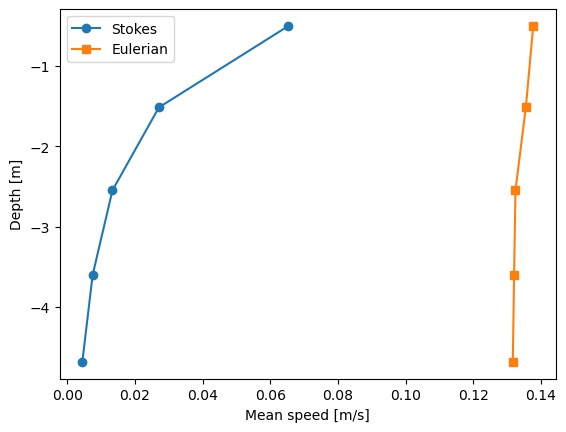

In [10]:
fig, ax = plt.subplots()

ax.plot(stokes_mean.values, -stokes_mean.depth.values, "o-", label="Stokes")
ax.plot(euler_mean.values, -euler_mean.depth.values, "s-", label="Eulerian")

ax.set_xlabel("Mean speed [m/s]")
ax.set_ylabel("Depth [m]")
ax.legend()
plt.show()

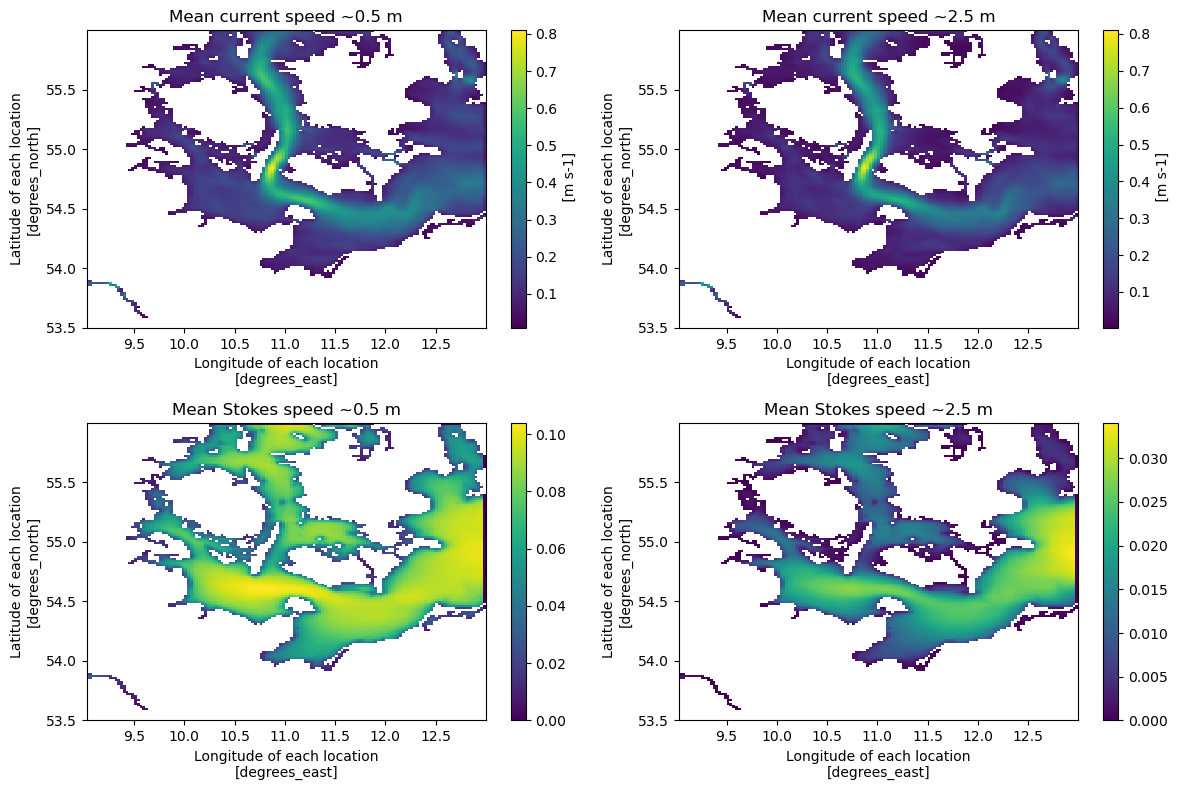

In [11]:
# Mean effective current speed and Stokes drift speed at ~0 m and ~3 m
current_speed_0 = np.sqrt(ds_eff["U_eff"] ** 2 + ds_eff["V_eff"] ** 2).sel(depth=0, method="nearest").mean("time")
current_speed_3 = np.sqrt(ds_eff["U_eff"] ** 2 + ds_eff["V_eff"] ** 2).sel(depth=3, method="nearest").mean("time")
stokes_speed_0 = np.sqrt(ds_eff["u_stokes"] ** 2 + ds_eff["v_stokes"] ** 2).sel(depth=0, method="nearest").mean("time")
stokes_speed_3 = np.sqrt(ds_eff["u_stokes"] ** 2 + ds_eff["v_stokes"] ** 2).sel(depth=3, method="nearest").mean("time")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

current_speed_0.plot(ax=axes[0, 0])
axes[0, 0].set_title(f"Mean current speed ~{float(current_speed_0.depth):.1f} m")

current_speed_3.plot(ax=axes[0, 1])
axes[0, 1].set_title(f"Mean current speed ~{float(current_speed_3.depth):.1f} m")

stokes_speed_0.plot(ax=axes[1, 0])
axes[1, 0].set_title(f"Mean Stokes speed ~{float(stokes_speed_0.depth):.1f} m")

stokes_speed_3.plot(ax=axes[1, 1])
axes[1, 1].set_title(f"Mean Stokes speed ~{float(stokes_speed_3.depth):.1f} m")

plt.tight_layout()
plt.show()